# Adam Optimizer on KMNIST

This experiment investigates the performance of the Adam optimizer on the KMNIST dataset using a feedforward neural network. Different learning rates and β1 values are explored to study their effect on convergence speed and classification accuracy.

## Import Libraries

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import KFold

import numpy as np
import matplotlib.pyplot as plt
import random
import time
import sys
import torchvision

## Set Seed

In [21]:
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
print("Random Seed:", seed)
print("Python Version:", sys.version)
print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

cpu
Random Seed: 42
Python Version: 3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
PyTorch Version: 2.11.0
Torchvision Version: 0.26.0


## Load Dataset

In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.KMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.KMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

## Neural Network Architecture

A feedforward neural network is used with:

- Input layer: 784 neurons
- Hidden layer 1: 128 neurons with ReLU activation
- Hidden layer 2: 64 neurons with ReLU activation
- Output layer: 10 neurons with softmax activation

The architecture remains fixed to ensure fair optimizer comparison.

In [5]:
class KMNISTNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = x.view(-1, 784)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        x = self.softmax(x)

        return x

## Loss Function

In [6]:
criterion = nn.CrossEntropyLoss()

## Adam Hyperparameter Configurations

Different combinations of learning rates and β1 values are investigated to determine the best-performing configuration.

Learning rates tested:

- 0.1
- 0.01
- 0.001
- 0.0001

β1 values tested:

- 0.85
- 0.90
- 0.95

In [7]:
adam_configs = [

    {"lr":0.001,"beta1":0.9},

    {"lr":0.01,"beta1":0.9},

    {"lr":0.001,"beta1":0.8},

    {"lr":0.0001,"beta1":0.9},

    {"lr":0.0001,"beta1":0.95}

]

## Training Function

In [8]:
def train_model(model, loader, optimizer):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return running_loss / len(loader), accuracy

## Validation Function

In [9]:
def evaluate_model(model, loader):

    model.eval()

    loss_total = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss_total += loss.item()

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return loss_total / len(loader), accuracy

## 5-Fold Cross Validation

In [10]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Hyperparameter Search

In [11]:
adam_results = []

for config in adam_configs:

    fold_accuracies = []

    print(config)

    for fold, (train_idx, val_idx) in enumerate(kfold.split(train_dataset)):

        train_subset = Subset(train_dataset, train_idx)
        val_subset = Subset(train_dataset, val_idx)

        train_loader = DataLoader(
            train_subset,
            batch_size=64,
            shuffle=True
        )

        val_loader = DataLoader(
            val_subset,
            batch_size=64
        )

        model = KMNISTNet().to(device)

        optimizer = optim.Adam(
            model.parameters(),
            lr=config["lr"],
            betas=(config["beta1"],0.999)
        )

        for epoch in range(20):

            train_model(model, train_loader, optimizer)

        _, val_acc = evaluate_model(model, val_loader)

        fold_accuracies.append(val_acc)

    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)

    adam_results.append(
        [config, mean_acc, std_acc]
    )

    print("Mean Accuracy:",mean_acc)
    print("Std:",std_acc)
    print()

{'lr': 0.001, 'beta1': 0.9}
Mean Accuracy: 92.47
Std: 1.0510523826675395

{'lr': 0.01, 'beta1': 0.9}
Mean Accuracy: 73.66
Std: 4.0795165835617775

{'lr': 0.001, 'beta1': 0.8}
Mean Accuracy: 92.55166666666666
Std: 0.8250488201043327

{'lr': 0.0001, 'beta1': 0.9}
Mean Accuracy: 84.61833333333333
Std: 0.3863792034891239

{'lr': 0.0001, 'beta1': 0.95}
Mean Accuracy: 84.39666666666668
Std: 0.3684652855652291



## Best Configuration

In [13]:
best_result = max(adam_results,key=lambda x:x[1])

print(best_result)

[{'lr': 0.001, 'beta1': 0.8}, np.float64(92.55166666666666), np.float64(0.8250488201043327)]


## Final Training

In [14]:
best_lr = best_result[0]["lr"]
best_beta1 = best_result[0]["beta1"]

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64
)

model = KMNISTNet().to(device)

optimizer = optim.Adam(
    model.parameters(),
    lr=best_lr,
    betas=(best_beta1,0.999)
)

## Train Model

In [15]:
epochs = 20

train_losses = []
test_losses = []

train_accs = []
test_accs = []

start = time.time()

for epoch in range(epochs):

    train_loss, train_acc = train_model(
        model,
        train_loader,
        optimizer
    )

    test_loss, test_acc = evaluate_model(
        model,
        test_loader
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Train Acc={train_acc:.2f}, "
        f"Test Acc={test_acc:.2f}"
    )

end = time.time()

training_time = end-start

Epoch 1/20, Train Acc=77.81, Test Acc=65.94
Epoch 2/20, Train Acc=84.05, Test Acc=70.04
Epoch 3/20, Train Acc=85.94, Test Acc=71.28
Epoch 4/20, Train Acc=87.64, Test Acc=73.37
Epoch 5/20, Train Acc=90.13, Test Acc=78.01
Epoch 6/20, Train Acc=91.25, Test Acc=78.14
Epoch 7/20, Train Acc=91.79, Test Acc=79.63
Epoch 8/20, Train Acc=92.32, Test Acc=79.45
Epoch 9/20, Train Acc=92.95, Test Acc=80.45
Epoch 10/20, Train Acc=93.64, Test Acc=81.22
Epoch 11/20, Train Acc=93.89, Test Acc=81.22
Epoch 12/20, Train Acc=94.17, Test Acc=82.30
Epoch 13/20, Train Acc=94.32, Test Acc=82.31
Epoch 14/20, Train Acc=95.12, Test Acc=87.52
Epoch 15/20, Train Acc=96.95, Test Acc=88.26
Epoch 16/20, Train Acc=97.34, Test Acc=88.61
Epoch 17/20, Train Acc=97.44, Test Acc=88.31
Epoch 18/20, Train Acc=97.63, Test Acc=88.56
Epoch 19/20, Train Acc=97.78, Test Acc=88.37
Epoch 20/20, Train Acc=97.86, Test Acc=89.03


## Final Accuracy

In [16]:
# Final performance metrics
print("Training Accuracy =", train_accs[-1])
print("Test Accuracy =", test_accs[-1])

print("Final Training Loss =", train_losses[-1])
print("Final Test Loss =", test_losses[-1])

print(f"Training Time = {training_time:.2f} seconds")

# Convergence speed
target_accuracy = 80

epoch_to_80 = next(
    (i + 1 for i, acc in enumerate(test_accs) if acc >= target_accuracy),
    None
)

print("Epoch reaching 80% accuracy =", epoch_to_80)

Training Accuracy = 97.85833333333333
Test Accuracy = 89.03
Final Training Loss = 1.4830122352408956
Final Test Loss = 1.5711828371521774
Training Time = 191.40 seconds
Epoch reaching 80% accuracy = 9


## Loss Curve

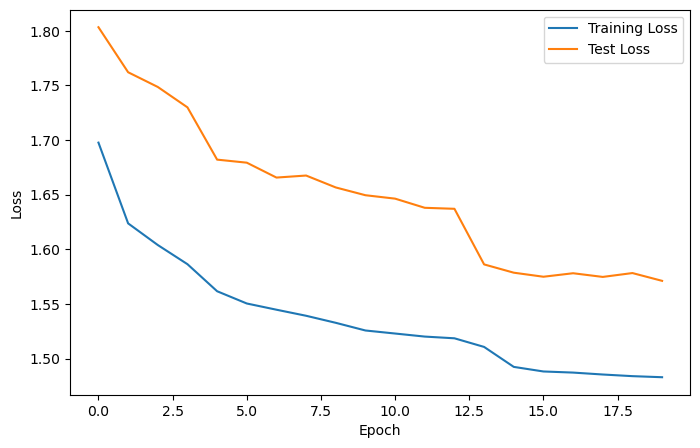

In [17]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)
plt.plot(test_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Test Loss"
])

plt.show()

## Accuracy Curve

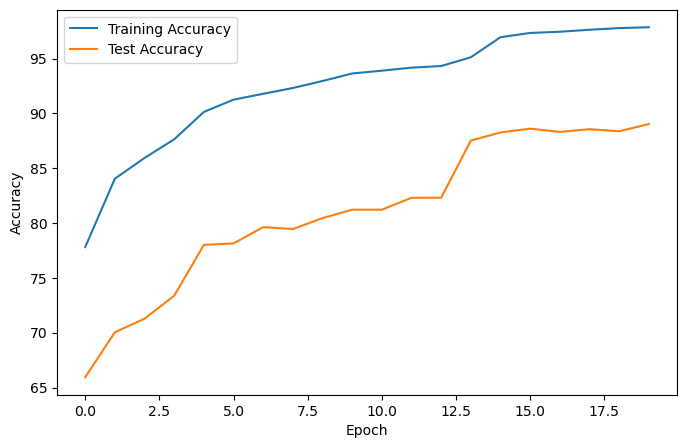

In [18]:
plt.figure(figsize=(8,5))

plt.plot(train_accs)
plt.plot(test_accs)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Test Accuracy"
])

plt.show()

In [22]:
summary_df = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Validation Accuracy",
        "Validation Std",
        "Test Accuracy",
        "Training Loss",
        "Test Loss",
        "Training Time (s)",
        "Epoch to 80%"
    ],

    "Value": [
        train_accs[-1],
        best_result[1],
        best_result[2],
        test_accs[-1],
        train_losses[-1],
        test_losses[-1],
        training_time,
        epoch_to_80
    ]
})

summary_df

,Metric,Value
0,Training Accuracy,97.858333
1,Validation Accuracy,92.551667
2,Validation Std,0.825049
3,Test Accuracy,89.030000
4,Training Loss,1.483012
5,Test Loss,1.571183
6,Training Time (s),191.397468
7,Epoch to 80%,9.000000


## Cross Validation Results

,Configuration,Mean Accuracy,Std
0,"{'lr': 0.001, 'beta1': 0.9}",92.470000,1.051052
1,"{'lr': 0.01, 'beta1': 0.9}",73.660000,4.079517
2,"{'lr': 0.001, 'beta1': 0.8}",92.551667,0.825049
3,"{'lr': 0.0001, 'beta1': 0.9}",84.618333,0.386379
4,"{'lr': 0.0001, 'beta1': 0.95}",84.396667,0.368465


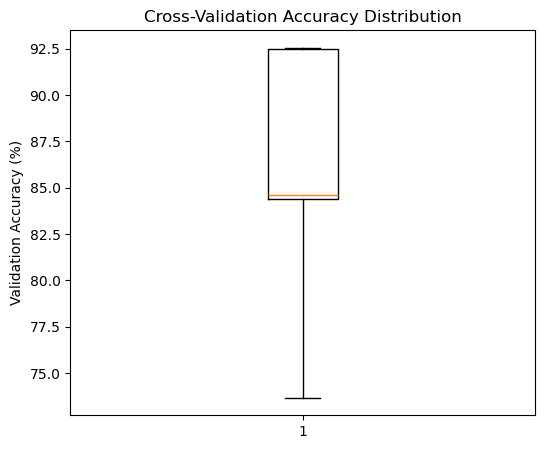

In [23]:
# Cross-validation results table
cv_results_df = pd.DataFrame(
    adam_results,
    columns=["Configuration", "Mean Accuracy", "Std"]
)

display(cv_results_df)

# Collect mean accuracies
cv_scores = cv_results_df["Mean Accuracy"]

# Boxplot
plt.figure(figsize=(6,5))

plt.boxplot(cv_scores)

plt.ylabel("Validation Accuracy (%)")
plt.title("Cross-Validation Accuracy Distribution")

plt.show()

# Optimizer Analysis

Adam exhibited stable convergence and achieved high accuracy throughout training. Moderate learning rates produced the best performance, while larger learning rates resulted in unstable optimization.

The difference between training accuracy and test accuracy was relatively small, indicating good generalization ability.

# Conclusion

In this experiment, the Adam optimizer was evaluated on the KMNIST dataset using different learning rates and β1 values.

The results showed that Adam achieved stable convergence and high classification accuracy. The best configuration provided strong performance and demonstrated good generalization on unseen data.

Overall, Adam proved to be an effective optimizer because of its adaptive learning mechanism and fast convergence. Adam is suitable for image classification and many practical deep learning applications.

## Limitations

1. Only a feedforward neural network architecture was considered.
2. A limited hyperparameter search space was explored.

## Future Work

Future studies may investigate deeper neural networks and larger hyperparameter search spaces to further improve performance.